# 2-Sample t-Test
## Hypothesis: Do diabetic patients have higher BMI than non-diabetic patients?
* **Ho (Null Hypothesis):** The mean BMI of diabetic patients is less than or equal to non-diabetic patients ($\mu_{diabetic} \le \mu_{non-diabetic}$).
* **Ha (Alternative Hypothesis):** The mean BMI of diabetic patients is greater than non-diabetic patients ($\mu_{diabetic} > \mu_{non-diabetic}$).

In [33]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower
from sklearn.preprocessing import MinMaxScaler # Added for normalization

# load dataset
file_path = r"C:\Users\ASUS\OneDrive\Desktop\dataset\diabetes_012_health_indicators_BRFSS2015.csv\diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path, delimiter=",")

# Display first few rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [34]:
# summary of statistics
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


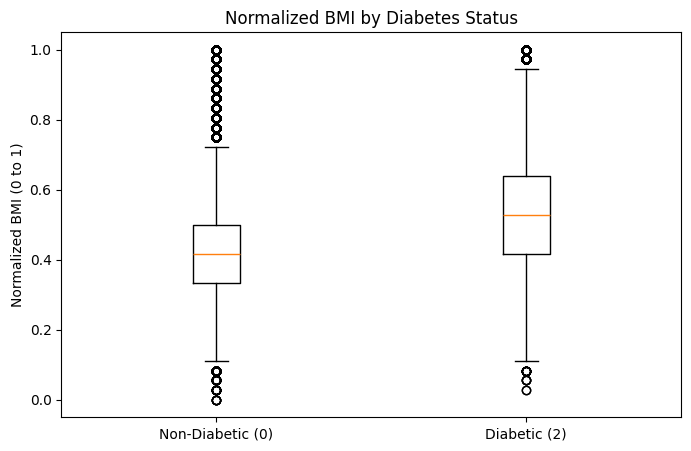

In [35]:
# 1. Data Cleaning: Removing 3-sigma outliers from the BMI column
z_scores = stats.zscore(df['BMI'])
outliers = (z_scores < -3) | (z_scores > 3)
df_cleaned = df[~outliers].copy() # .copy() prevents warnings when adding new columns

# 2. Normalization: Apply Min-Max Scaling to the BMI column
scaler = MinMaxScaler()
df_cleaned['BMI_normalized'] = scaler.fit_transform(df_cleaned[['BMI']])

# Extract the two groups using the NORMALIZED BMI (0.0 = Non-diabetic, 2.0 = Diabetic)
non_diabetic_bmi = df_cleaned[df_cleaned['Diabetes_012'] == 0.0]['BMI_normalized']
diabetic_bmi = df_cleaned[df_cleaned['Diabetes_012'] == 2.0]['BMI_normalized']

# Check for outliers visually in both groups using normalized data
plt.figure(figsize=(8, 5))
plt.boxplot([non_diabetic_bmi, diabetic_bmi], tick_labels=['Non-Diabetic (0)', 'Diabetic (2)'])
plt.title('Normalized BMI by Diabetes Status')
plt.ylabel('Normalized BMI (0 to 1)')
plt.show()

In [36]:
# shapiro-wilk normality test
print("Non-Diabetic BMI:")
w_stat_nd, p_value_nd = stats.shapiro(non_diabetic_bmi)
print(f"w_stat: {w_stat_nd:.4f}")
print(f"P-value: {p_value_nd:.4f}")

if p_value_nd < 0.05:
    print("Non-normal data\n")
else:
    print("Normal data\n")
    
print("Diabetic BMI:")
w_stat_d, p_value_d = stats.shapiro(diabetic_bmi)
print(f"w_stat: {w_stat_d:.4f}")
print(f"P-value: {p_value_d:.4f}")

if p_value_d < 0.05:
    print("Non-normal data")
else:
    print("Normal data")

Non-Diabetic BMI:
w_stat: 0.9562
P-value: 0.0000
Non-normal data

Diabetic BMI:
w_stat: 0.9790
P-value: 0.0000
Non-normal data


c:\Users\ASUS\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 211852.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\ASUS\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 34329.
  res = hypotest_fun_out(*samples, **kwds)


In [37]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_diabetic = var_non_diabetic
Ha: var_diabetic != var_non_diabetic
"""

var_d = diabetic_bmi.var(ddof=1)
var_nd = non_diabetic_bmi.var(ddof=1)

# F-statistic
if var_d > var_nd:
    f_stat = var_d / var_nd
    df1 = len(diabetic_bmi) - 1
    df2 = len(non_diabetic_bmi) - 1
else:
    f_stat = var_nd / var_d
    df1 = len(non_diabetic_bmi) - 1
    df2 = len(diabetic_bmi) - 1

print(f'f_stat = {f_stat:.4f}')

# probability value
p_value = 1 - stats.f.cdf(f_stat, df1, df2)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print("Unequal variances (Reject Ho)")
    equal_var_flag = False
else:
    print("Equal variances (Fail to reject Ho)")
    equal_var_flag = True

f_stat = 1.2778
p_value = 0.0000
Unequal variances (Reject Ho)


In [42]:
"""
2-Sample T-Test for Independent Samples (Right-tailed)
----------------------------------------
Ho: Diabetic BMI <= Non-Diabetic BMI
Ha: Diabetic BMI > Non-Diabetic BMI
"""

# We use alternative='greater' because we are testing if the first array (diabetic) is GREATER than the second
t_stat, p_value = stats.ttest_ind(diabetic_bmi, non_diabetic_bmi, 
                                  alternative='greater', 
                                  equal_var=equal_var_flag)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print("Diabetic patients have a significantly " + "\n" + " higher BMI than non-diabetic patients.")
else:
    print("There is no significant evidence that diabetic patients have a higher BMI.")

t_stat = 109.5394
p_value = 0.0000
Diabetic patients have a significantly 
 higher BMI than non-diabetic patients.


In [39]:
# cohen's d
mean_d = diabetic_bmi.mean()
mean_nd = non_diabetic_bmi.mean()

# Using the standard deviation of the diabetic group as the denominator for the pooled approximation
std_d = diabetic_bmi.std(ddof=1) 

d = abs((mean_d - mean_nd) / std_d)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = d, 
    nobs = len(diabetic_bmi),
    alpha = 0.05,
    alternative = "larger"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.6276
Power of the test: 100.00%
